In [13]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import json

# import all json files
with open("eval_results/evaluation_metrics_bert.json", "r") as f:
    bert_metrics = json.load(f)

with open("eval_results/evaluation_metrics_dictionary.json", "r") as f:
    dictionary_metrics = json.load(f)

with open("eval_results/evaluation_metrics_gpt.json", "r") as f:
    gpt_results = json.load(f)

# combine all models
all_metrics = {**bert_metrics, **dictionary_metrics, **gpt_results}

# rename cross-span to cross_span
for model in all_metrics:
    if "cross-span" in all_metrics[model]:
        all_metrics[model]["cross_span"] = all_metrics[model].pop("cross-span")

# reorder the dictionary
all_metrics = dict(
    (k, all_metrics[k]) for k in [
        'microsoft/deberta-v3-base',
        'roberta-base',
        'bert-base-cased',
        'distilbert-base-cased',
        'dictionary_baseline',
        'gpt-5-nano',
        'gpt-4o-mini'
    ]
)

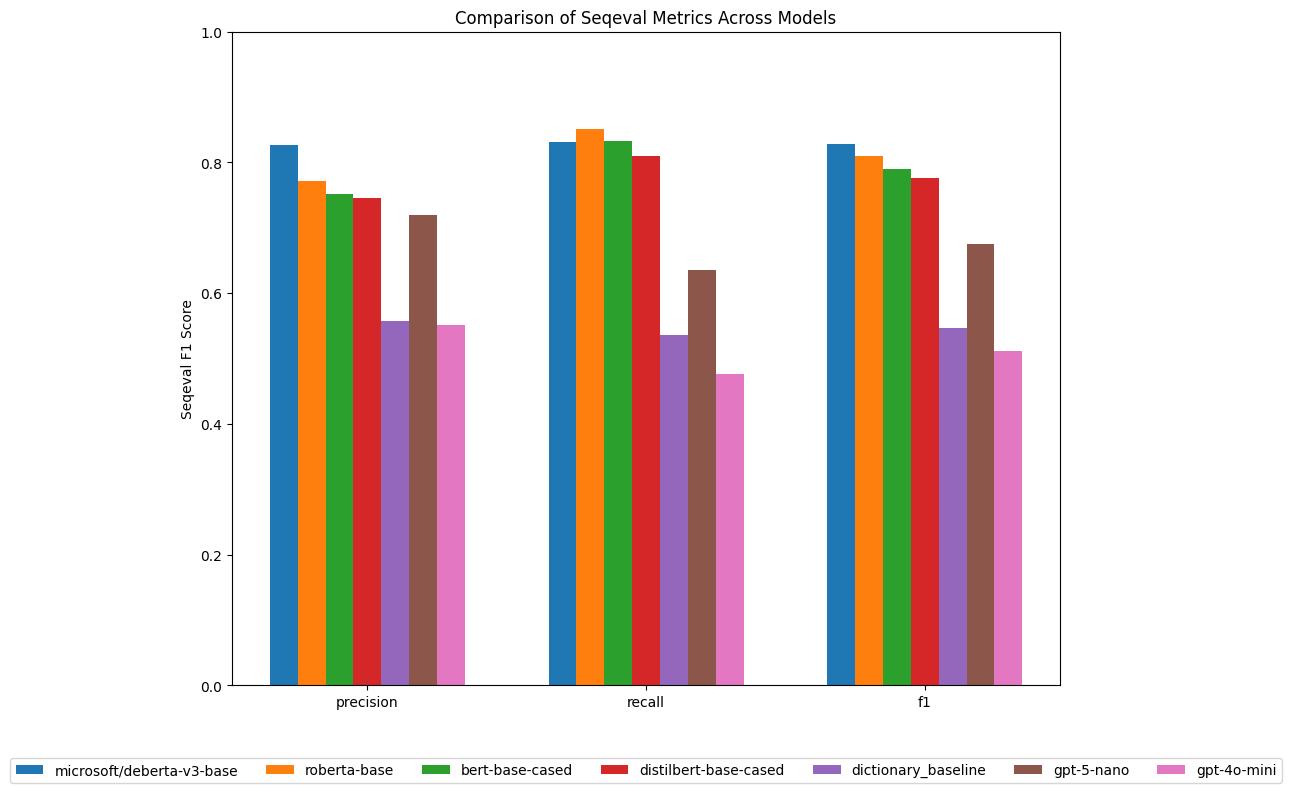

In [14]:
# get only the seqeval metrics
models = list(all_metrics.keys())
metrics = ['precision', 'recall', 'f1']
values = np.array([[all_metrics[m]['seqeval'][metric] for metric in metrics] for m in models])

# create the plot
x = np.arange(len(metrics))
width = 0.1
fig, ax = plt.subplots(figsize=(12, 8))
for i, model in enumerate(models):
    ax.bar(x + i*width, values[i], width, label=model)
ax.set_xticks(x + width*(len(models)-1)/2)
ax.set_xticklabels(metrics)
ax.set_ylabel('Seqeval F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Comparison of Seqeval Metrics Across Models')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(models))
plt.tight_layout()
plt.show()

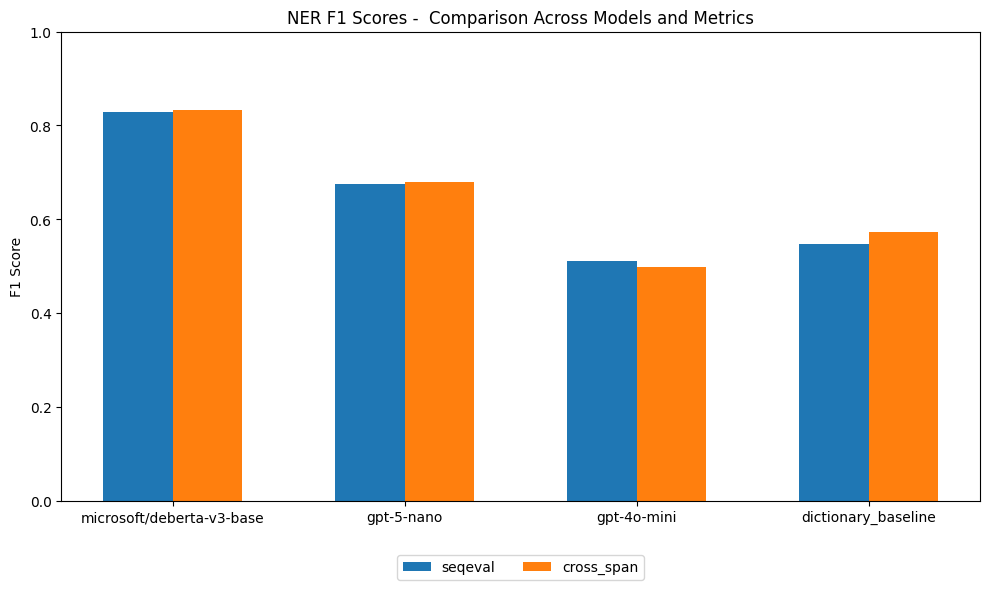

In [19]:
# define the models to look at
models = ['microsoft/deberta-v3-base', 'gpt-5-nano', 'gpt-4o-mini', 'dictionary_baseline']

# define all metrics
sub_metrics = ['seqeval', 'cross_span']

# extract all f1 scores
f1_values = np.array([[all_metrics[m][sub]['f1'] for sub in sub_metrics] for m in models])

# create the plot
x = np.arange(len(models))
width = 0.3
fig, ax = plt.subplots(figsize=(10, 6))
for i, sub in enumerate(sub_metrics):
    ax.bar(x + i*width, f1_values[:, i], width, label=sub)
ax.set_xticks(x + width/2)
ax.set_xticklabels(models)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('NER F1 Scores -  Comparison Across Models and Metrics')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(sub_metrics))
plt.tight_layout()
plt.show()